In [1]:
import pandas as pd
import numpy as np

from scipy.stats import poisson

import pickle

import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
# cargamos archivo con el estado actual de cada seleccion
team_strength = pd.read_csv(
    "../data/processed/team_strength.csv",
    index_col=0
)

In [21]:
team_strength.shape

(304, 5)

In [22]:
# Carga los modelos entrenados.
with open(
    "../models/home_poisson.pkl",
    "rb"
) as f:

    home_results = pickle.load(f)

with open(
    "../models/away_poisson.pkl",
    "rb"
) as f:

    away_results = pickle.load(f)

In [23]:
#  Convierte dos selecciones en goles esperados utilizando los modelos Poisson.
def predict_match(home_team, away_team):

    home = team_strength.loc[home_team]
    away = team_strength.loc[away_team]

    elo_diff = (
        home["elo"]
        - away["elo"]
    )

    home_data = pd.DataFrame({
        "const": [1],
        "elo_diff": [elo_diff],

        "home_form_5": [home["form_5"]],
        "away_form_5": [away["form_5"]],

        "home_avg_goals_5": [home["avg_goals_5"]],
        "away_avg_goals_5": [away["avg_goals_5"]],

        "home_avg_conceded_5": [home["avg_conceded_5"]],
        "away_avg_conceded_5": [away["avg_conceded_5"]],

        "home_avg_goal_diff_5": [home["avg_goal_diff_5"]],
        "away_avg_goal_diff_5": [away["avg_goal_diff_5"]]
    })

    lambda_home = home_results.predict(
        home_data
    )[0]

    away_data = pd.DataFrame({
        "const": [1],

        "away_elo_diff": [-elo_diff],

        "away_form_5": [away["form_5"]],
        "home_form_5": [home["form_5"]],

        "away_avg_goals_5": [away["avg_goals_5"]],
        "home_avg_goals_5": [home["avg_goals_5"]],

        "away_avg_conceded_5": [away["avg_conceded_5"]],
        "home_avg_conceded_5": [home["avg_conceded_5"]],

        "away_avg_goal_diff_5": [away["avg_goal_diff_5"]],
        "home_avg_goal_diff_5": [home["avg_goal_diff_5"]]
    })

    lambda_away = away_results.predict(
        away_data
    )[0]

    return {
        "home_team": home_team,
        "away_team": away_team,
        "lambda_home": float(lambda_home),
        "lambda_away": float(lambda_away)
    }

In [6]:
# Simula un partido real con Poisson
def simulate_match(
    home_team,
    away_team
):

    prediction = predict_match(
        home_team,
        away_team
    )

    home_goals = poisson.rvs(
        prediction["lambda_home"]
    )

    away_goals = poisson.rvs(
        prediction["lambda_away"]
    )

    return (
        home_goals,
        away_goals
    )

In [7]:
for _ in range(10):

    print(
        simulate_match(
            "Argentina",
            "Brazil"
        )
    )

(2, 0)
(0, 1)
(0, 0)
(0, 1)
(1, 2)
(3, 0)
(2, 0)
(0, 2)
(0, 0)
(2, 1)


In [25]:
# Obtiene los porcentajes de victoria (local/visitante), empate y derrota (local/visitante)
def monte_carlo_match(
    home_team,
    away_team,
    simulations=10000
):

    home_wins = 0
    draws = 0
    away_wins = 0

    for _ in range(simulations):

        hg, ag = simulate_match(
            home_team,
            away_team
        )

        if hg > ag:

            home_wins += 1

        elif hg < ag:

            away_wins += 1

        else:

            draws += 1

    return {

        "home_team": home_team,
        "away_team": away_team,

        "home_win":
        home_wins / simulations,

        "draw":
        draws / simulations,

        "away_win":
        away_wins / simulations
    }

In [26]:
results = monte_carlo_match(
    "Argentina",
    "Brazil",
    simulations=10000
)

results

{'home_team': 'Argentina',
 'away_team': 'Brazil',
 'home_win': 0.6147,
 'draw': 0.231,
 'away_win': 0.1543}

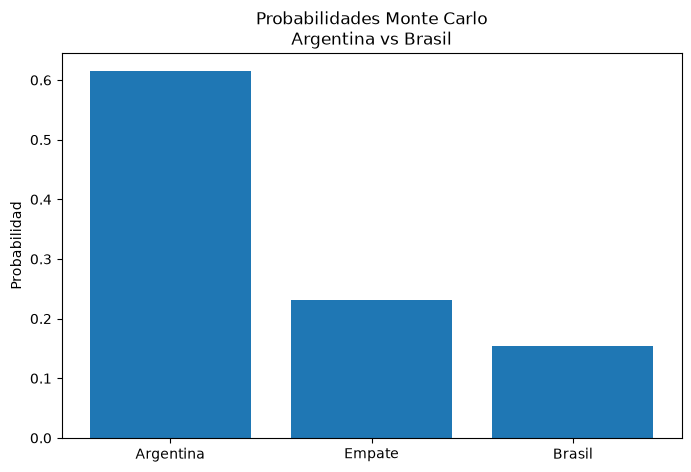

In [27]:
labels = [
    "Argentina",
    "Empate",
    "Brasil"
]

values = [
    results["home_win"],
    results["draw"],
    results["away_win"]
]

plt.figure(figsize=(8,5))

plt.bar(
    labels,
    values
)

plt.title(
    "Probabilidades Monte Carlo\nArgentina vs Brasil"
)

plt.ylabel(
    "Probabilidad"
)

plt.show()

In [28]:
# obtiene aproximaciones utilizando la distribución de Poisson. segudno modelo 
def match_probabilities(
    home_team,
    away_team,
    max_goals=10
):

    prediction = predict_match(
        home_team,
        away_team
    )

    home_lambda = prediction["lambda_home"]
    away_lambda = prediction["lambda_away"]

    home_win = 0
    draw = 0
    away_win = 0

    for home_goals in range(max_goals + 1):

        for away_goals in range(max_goals + 1):

            probability = (
                poisson.pmf(
                    home_goals,
                    home_lambda
                )
                *
                poisson.pmf(
                    away_goals,
                    away_lambda
                )
            )

            if home_goals > away_goals:

                home_win += probability

            elif home_goals < away_goals:

                away_win += probability

            else:

                draw += probability

    return {

        "home_team": home_team,
        "away_team": away_team,

        "home_win": home_win,
        "draw": draw,
        "away_win": away_win
    }

In [32]:
# comparamos con simulacion de monte carlo
theoretical = match_probabilities(
    "Argentina",
    "Brazil"
)

theoretical

{'home_team': 'Argentina',
 'away_team': 'Brazil',
 'home_win': np.float64(0.6176617080264475),
 'draw': np.float64(0.22682876684225722),
 'away_win': np.float64(0.15550660055276458)}